# Is Alabama Getting Wetter? Temerature and Precipitation Trends Across Seasons (1900-2026)

### Scientific Question

Has Alabama's wet (Jan–Mar) precipitation intensity changed over 125 years, and does warmer temperature correlate with heavier rainfall?

### Hypothesis

We hypothesize that wet season (January–March) precipitation has increased over time, consistent with the "wet gets wetter" climate theory, while dry season (August–October) trends remain weaker. We also hypothesize that warmer average temperatures correlate with higher precipitation during the wet season.

### Load Datasets

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
plt.rcParams["figure.figsize"] = (12, 6)

In [8]:
# Rebuild wet season precipitation (Jan–Mar) 
# This replicates Sophie's Step 1 output for my own notebook to be standalone

jan_data = pd.read_csv(
    'https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/statewide/time-series/1/pcp/1/1/1900-2026/data.csv',
    names=['year', 'precip'], skiprows=3
)
feb_data = pd.read_csv(
    'https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/statewide/time-series/1/pcp/1/2/1900-2026/data.csv',
    names=['year', 'precip'], skiprows=3
)
mar_data = pd.read_csv(
    'https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/statewide/time-series/1/pcp/1/3/1900-2026/data.csv',
    names=['year', 'precip'], skiprows=3
)

jan_data['year'] = jan_data['year'].astype(str).str[:4]
feb_data['year'] = jan_data['year'].astype(str).str[:4]
mar_data['year'] = jan_data['year'].astype(str).str[:4]

wet = jan_data.merge(feb_data, on='year', suffixes=("_jan", "_feb"))
wet = wet.merge(mar_data, on="year")
wet["wet_season_avg"] = (wet['precip_jan'] + wet['precip_feb'] + wet['precip']) / 3
wet['year'] = wet['year'].astype(float)

In [9]:
# Rebuild dry season precipitation (Aug–Oct) 
# I am replicating Sophie's Step 2 output so my notebook can be standalone

aug_data = pd.read_csv(
    'https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/statewide/time-series/1/pcp/1/8/1900-2026/data.csv',
    names=['year', 'precip'], skiprows=3
)
sep_data = pd.read_csv(
    'https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/statewide/time-series/1/pcp/1/9/1900-2026/data.csv',
    names=['year', 'precip'], skiprows=3
)
oct_data = pd.read_csv(
    'https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/statewide/time-series/1/pcp/1/10/1900-2026/data.csv',
    names=['year', 'precip'], skiprows=3
)

aug_data['year'] = aug_data['year'].astype(str).str[:4]
sep_data['year'] = aug_data['year'].astype(str).str[:4]
oct_data['year'] = aug_data['year'].astype(str).str[:4]

dry = aug_data.merge(sep_data, on='year', suffixes=("_aug", "_sep"))
dry = dry.merge(oct_data, on="year")
dry["dry_season_avg"] = (dry['precip_aug'] + dry['precip_sep'] + dry['precip']) / 3
dry['year'] = dry['year'].astype(float)

### Step 4 - Wet Season Testing

Now, we want to create a scatter plot of average wet season temperature vs. average wet season precipitation to assess whether warmer years tend to be wetter.

In [10]:
# Load average temperature data for Alabama wet season months (Jan, Feb, Mar)
# NOAA URL: swap 'pcp' with 'tavg' for average temperature
jan_temp = pd.read_csv(
    'https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/statewide/time-series/1/tavg/1/1/1900-2026/data.csv',
    names=['year', 'temp'], skiprows=3
)
feb_temp = pd.read_csv(
    'https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/statewide/time-series/1/tavg/1/2/1900-2026/data.csv',
    names=['year', 'temp'], skiprows=3
)
mar_temp = pd.read_csv(
    'https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/statewide/time-series/1/tavg/1/3/1900-2026/data.csv',
    names=['year', 'temp'], skiprows=3
)

# Extract 4-digit year from YYYYMM
for df in [jan_temp, feb_temp, mar_temp]:
    df['year'] = df['year'].astype(str).str[:4]

jan_temp.head(3)

,year,temp
0,1900,43.6
1,1901,46.0
2,1902,43.2


In [11]:
# Average wet season temperature per year across Jan, Feb, Mar
wet_temp = jan_temp[['year']].copy()
wet_temp['wet_temp_avg'] = (
    jan_temp['temp'].values +
    feb_temp['temp'].values +
    mar_temp['temp'].values
) / 3

# to respect Sophie's code and match dtype, wet['year'] was cast to float back in Step 1 (wet['year'] = wet['year'].astype(float))
wet_temp['year'] = wet_temp['year'].astype(float)

# Merge with wet season precipitation (built in Step 1)
wet_merged = pd.merge(wet[['year', 'wet_season_avg']], wet_temp, on='year')
wet_merged['year'] = wet_merged['year'].astype(int)
wet_merged.head()

,year,wet_season_avg,wet_temp_avg
0,1900,6.026667,46.966667
1,1901,5.253333,47.466667
2,1902,6.666667,46.366667
3,1903,6.616667,50.366667
4,1904,4.050000,49.366667


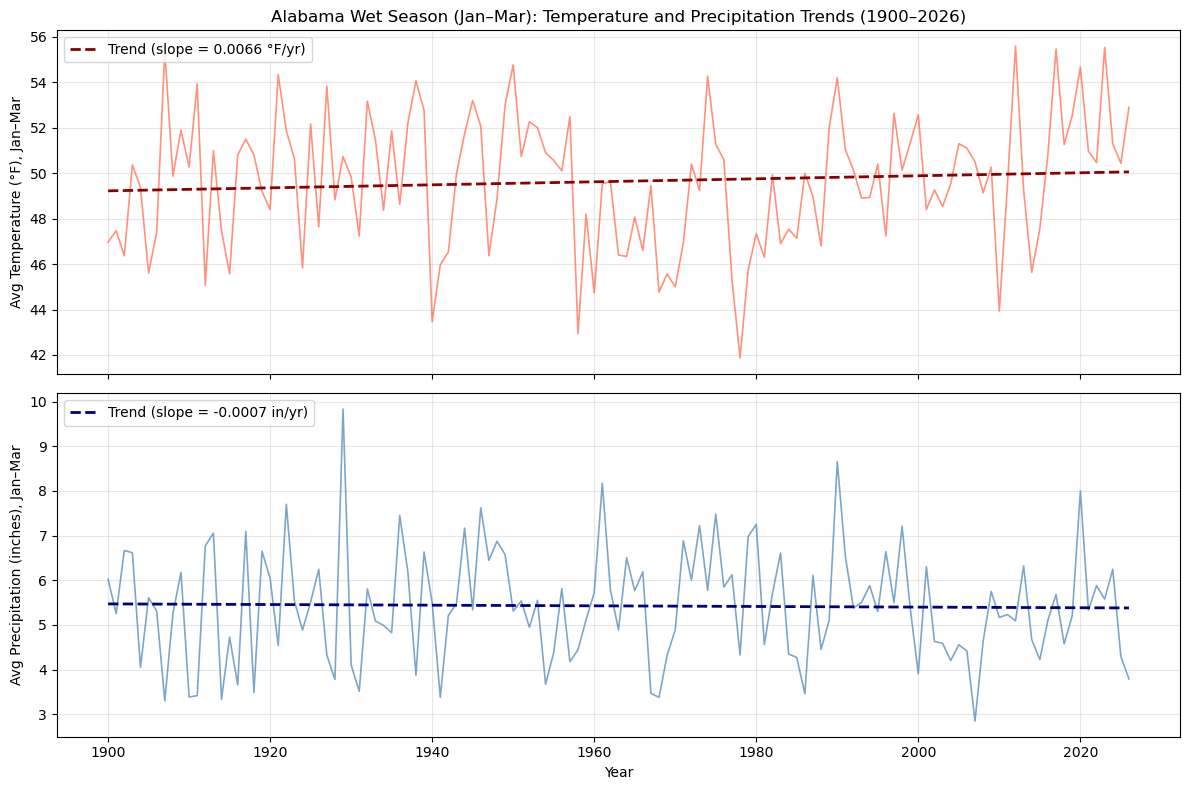

In [12]:
# Step 3a: Dual time-series — wet season temperature and precipitation side by side
# This shows each variable individually before comparing them in the scatter plot

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# --- Top panel: wet season average temperature over time ---
ax1.plot(wet_merged['year'], wet_merged['wet_temp_avg'], color='tomato', linewidth=1.2, alpha=0.7)

# Trend line for temperature
z_temp = np.polyfit(wet_merged['year'], wet_merged['wet_temp_avg'], 1)
p_temp = np.poly1d(z_temp)
ax1.plot(wet_merged['year'], p_temp(wet_merged['year']), color='darkred', linewidth=2,
         linestyle='--', label=f'Trend (slope = {z_temp[0]:.4f} °F/yr)')

ax1.set_ylabel('Avg Temperature (°F), Jan–Mar')
ax1.set_title("Alabama Wet Season (Jan–Mar): Temperature and Precipitation Trends (1900–2026)")
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# --- Bottom panel: wet season average precipitation over time ---
ax2.plot(wet_merged['year'], wet_merged['wet_season_avg'], color='steelblue', linewidth=1.2, alpha=0.7)

# Trend line for precipitation
z_precip = np.polyfit(wet_merged['year'], wet_merged['wet_season_avg'], 1)
p_precip = np.poly1d(z_precip)
ax2.plot(wet_merged['year'], p_precip(wet_merged['year']), color='navy', linewidth=2,
         linestyle='--', label=f'Trend (slope = {z_precip[0]:.4f} in/yr)')

ax2.set_xlabel('Year')
ax2.set_ylabel('Avg Precipitation (inches), Jan–Mar')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Observation: The two panels above show how wet season temperature (top) and precipitation (bottom) have each evolved independently over 125 years. We see that temperature has increased over time in the dry season with an increase of 0.0066F per year. Precipitation, surprisinlgy, seems to have lightly declined by 0.0007 inches per year over time during dry season in Alabama. 

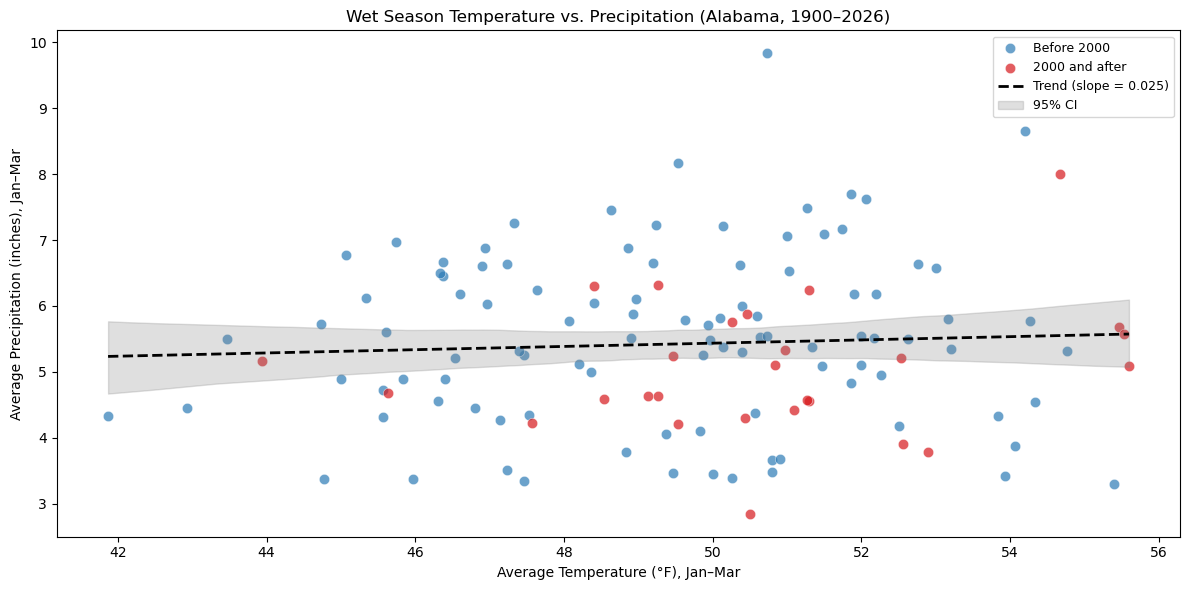

In [13]:
# Wet season scatter plot: temperature vs precipitation, pre/post 2000
wet_merged['era'] = wet_merged['year'].apply(lambda y: 'Before 2000' if y < 2000 else '2000 and after')
era_colors = {'Before 2000': '#2c7bb6', '2000 and after': '#d7191c'}

fig, ax = plt.subplots(figsize=(12, 6))

for era, color in era_colors.items():
    mask = wet_merged['era'] == era
    ax.scatter(
        wet_merged.loc[mask, 'wet_temp_avg'],
        wet_merged.loc[mask, 'wet_season_avg'],
        color=color, label=era, alpha=0.7, s=55, edgecolors='white', linewidths=0.4
    )

# Linear regression + confidence band
x = wet_merged['wet_temp_avg'].values
y = wet_merged['wet_season_avg'].values
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 200)
y_line = m * x_line + b

rng = np.random.default_rng(0)
boot_lines = []
for _ in range(500):
    idx = rng.integers(0, len(x), len(x))
    mb = np.polyfit(x[idx], y[idx], 1)
    boot_lines.append(mb[0] * x_line + mb[1])
boot_lines = np.array(boot_lines)
lower, upper = np.percentile(boot_lines, [2.5, 97.5], axis=0)

ax.plot(x_line, y_line, color='black', linewidth=2, linestyle='--',
        label=f'Trend (slope = {m:.3f})')
ax.fill_between(x_line, lower, upper, color='gray', alpha=0.25, label='95% CI')

ax.set_title('Wet Season Temperature vs. Precipitation (Alabama, 1900–2026)')
ax.set_xlabel('Average Temperature (°F), Jan–Mar')
ax.set_ylabel('Average Precipitation (inches), Jan–Mar')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Observation: The relatively flat trend slope of 0.025 means warmer wet seasons in Alabama are not meaningfully associated with more rainfall over 125 years. I decided to visualize the difference between after year 2000 and before 2000 in red and blue because I was curious to see if precipitation events tend to be more exreme in recent years in the wet season. From this graph, temperature alone explains very little of the variation in wet season rainfall. Storms and other climate variability is likley more relevant when it comes to precipitation events in the wet season.  

In [14]:
# now i want to test the correlation through a statistical test:pearson 

from scipy import stats

# Pearson correlation between wet season avg temperature and avg precipitation
r, p_value = stats.pearsonr(wet_merged['wet_temp_avg'], wet_merged['wet_season_avg'])

print(f"Pearson Correlation Coefficient (r): {r:.4f}")
print(f"P-value:                             {p_value:.4f}")
print()

if p_value < 0.05:
    print("Result: The correlation IS statistically significant (p < 0.05).")
else:
    print("Result: The correlation is NOT statistically significant (p >= 0.05).")

if abs(r) < 0.2:
    strength = "negligible"
elif abs(r) < 0.4:
    strength = "weak"
elif abs(r) < 0.6:
    strength = "moderate"
else:
    strength = "strong"

direction = "positive" if r > 0 else "negative"
print(f"Interpretation: {strength.capitalize()} {direction} correlation between wet season temperature and precipitation.")

Pearson Correlation Coefficient (r): 0.0566
P-value:                             0.5274

Result: The correlation is NOT statistically significant (p >= 0.05).
Interpretation: Negligible positive correlation between wet season temperature and precipitation.


Observation: there are no significant relationships in the wet season.  

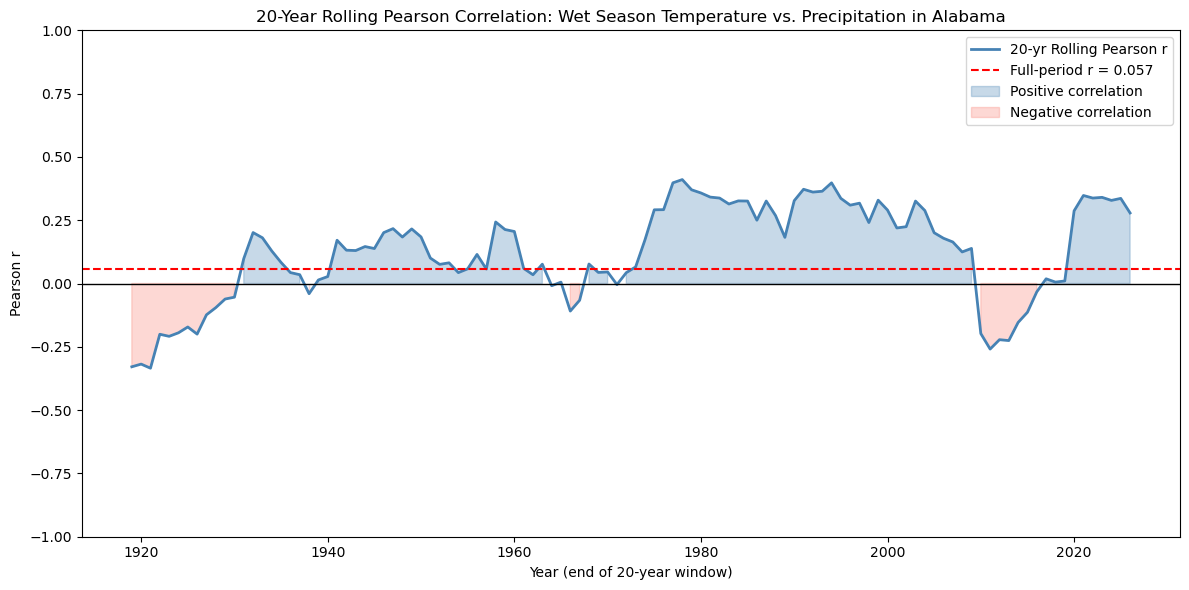

In [15]:
# Rolling 20-year Pearson correlation to detect shifts in the temp-precip relationship
window = 20
rolling_r = [
    stats.pearsonr(
        wet_merged['wet_temp_avg'].iloc[i:i+window].values,
        wet_merged['wet_season_avg'].iloc[i:i+window].values
    )[0]
    for i in range(len(wet_merged) - window + 1)
]
rolling_r = np.array(rolling_r)
rolling_years = wet_merged['year'].iloc[window - 1:].values

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(rolling_years, rolling_r, color='steelblue', linewidth=2, label='20-yr Rolling Pearson r')
ax.axhline(0, color='black', linewidth=1)
ax.axhline(r, color='red', linewidth=1.5, linestyle='--', label=f'Full-period r = {r:.3f}')

ax.fill_between(rolling_years, rolling_r, 0,
                where=(rolling_r >= 0), color='steelblue', alpha=0.3, label='Positive correlation')
ax.fill_between(rolling_years, rolling_r, 0,
                where=(rolling_r < 0), color='salmon', alpha=0.3, label='Negative correlation')

ax.set_title("20-Year Rolling Pearson Correlation: Wet Season Temperature vs. Precipitation in Alabama")
ax.set_xlabel("Year (end of 20-year window)")
ax.set_ylabel("Pearson r")
ax.set_ylim(-1, 1)
ax.legend()
plt.tight_layout()
plt.show()

Observation: Periods where the rolling r exceeds the full-period average (red dashed line) indicate decades when warmer wet seasons were especially associated with increased rainfall. Periods of negative r suggest years when the relationship reversed, possibly driven by large-scale climate oscillations such as ENSO, stomrs or the Atlantic Multidecadal Oscillation. This graph shows that whatever drives wet season rainfall in Alabama is complex and not well captured by temperature alone. There are a lot of back and forth between positive and negative relationships, but rolling r is barely above 0. 

A rolling Pearson correlation measures the linear relationship between the two time-series variables across a sliding, fixed-size window. It helps visualize how the strength and direction of a correlation (ranging from -1 to 1) fluctuate over time rather than remaining constant.

### Step 5: Dry Season: Precipitation vs Temperature Testing

In [16]:
#DRY SEASON ANALYSIS: Temperature vs Precipitation (Aug–Oct) in Alabama

# Load dry season temperature data (Aug, Sep, Oct) from NOAA
aug_temp = pd.read_csv(
    'https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/statewide/time-series/1/tavg/1/8/1900-2026/data.csv',
    names=['year', 'temp'], skiprows=3
)
sep_temp = pd.read_csv(
    'https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/statewide/time-series/1/tavg/1/9/1900-2026/data.csv',
    names=['year', 'temp'], skiprows=3
)
oct_temp = pd.read_csv(
    'https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/statewide/time-series/1/tavg/1/10/1900-2026/data.csv',
    names=['year', 'temp'], skiprows=3
)

# Extract 4-digit year, match Sophie's float dtype
for df in [aug_temp, sep_temp, oct_temp]:
    df['year'] = df['year'].astype(str).str[:4].astype(float)

# Average the three months into one dry season temperature per year
dry_temp = aug_temp[['year']].copy()
dry_temp['dry_temp_avg'] = (
    aug_temp['temp'].values +
    sep_temp['temp'].values +
    oct_temp['temp'].values
) / 3

# Merge with Sophie's dry season precipitation (compare it with my temperature table)
# dry['dry_season_avg'] contains Aug–Oct avg precipitation per year for that dry season
dry_merged = pd.merge(dry[['year', 'dry_season_avg']], dry_temp, on='year')
dry_merged['year'] = dry_merged['year'].astype(int)
dry_merged.head()

,year,dry_season_avg,dry_temp_avg
0,1900,4.323333,75.666667
1,1901,4.943333,71.200000
2,1902,3.873333,73.000000
3,1903,2.700000,72.333333
4,1904,2.433333,73.400000


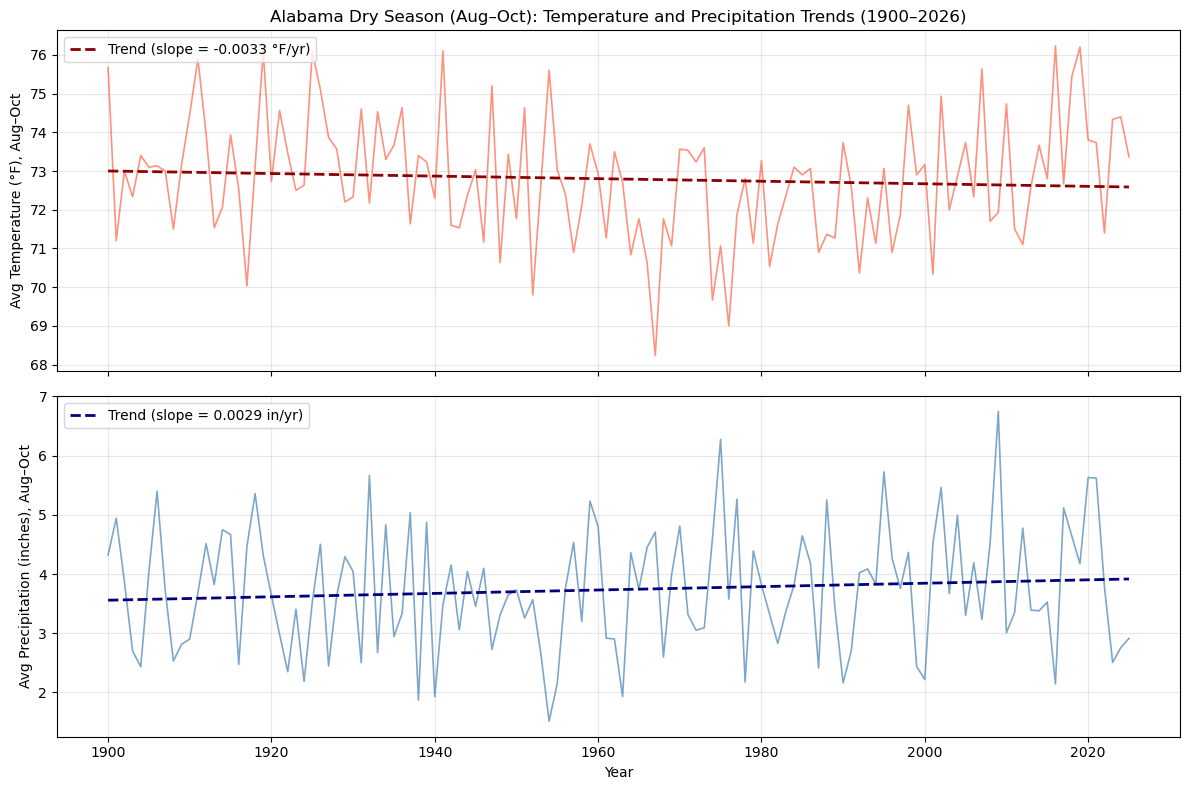

In [17]:
#Dry season temperature and precipitation trends over time:

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top panel: dry season temperature trend
ax1.plot(dry_merged['year'], dry_merged['dry_temp_avg'], color='tomato', linewidth=1.2, alpha=0.7)
z_temp = np.polyfit(dry_merged['year'], dry_merged['dry_temp_avg'], 1)
p_temp = np.poly1d(z_temp)
ax1.plot(dry_merged['year'], p_temp(dry_merged['year']), color='darkred', linewidth=2,
         linestyle='--', label=f'Trend (slope = {z_temp[0]:.4f} °F/yr)')
ax1.set_ylabel('Avg Temperature (°F), Aug–Oct')
ax1.set_title('Alabama Dry Season (Aug–Oct): Temperature and Precipitation Trends (1900–2026)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Bottom panel: dry season precipitation trend
ax2.plot(dry_merged['year'], dry_merged['dry_season_avg'], color='steelblue', linewidth=1.2, alpha=0.7)
z_precip = np.polyfit(dry_merged['year'], dry_merged['dry_season_avg'], 1)
p_precip = np.poly1d(z_precip)
ax2.plot(dry_merged['year'], p_precip(dry_merged['year']), color='navy', linewidth=2,
         linestyle='--', label=f'Trend (slope = {z_precip[0]:.4f} in/yr)')
ax2.set_xlabel('Year')
ax2.set_ylabel('Avg Precipitation (inches), Aug–Oct')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The above graphs show how temperature and rainfall changed independelty over 125 years. Precipitation has a slope of 0.0029 inches/ year increase, and temperatures decreased by 0.0033 degree Farenheit per year. The fact that temperatures in Alabama during the dry season have decreased is somewhat suprising given global warming, but that could represent natural variability over 125 years. When looking at the top graph, temperatures seem to continually increase between 1980 and 2020. It is likely that temperatures will increase again, especially as the Northern Hemisphere is being hit with heatwaves during summer seasons. An upward trend in precipitation would indicate that precipitation is increasing, through floods for example, as highlighted in the following EPA paper regarding Alabama and the risks for floods: https://19january2017snapshot.epa.gov/sites/production/files/2016-09/documents/climate-change-al.pdf. 

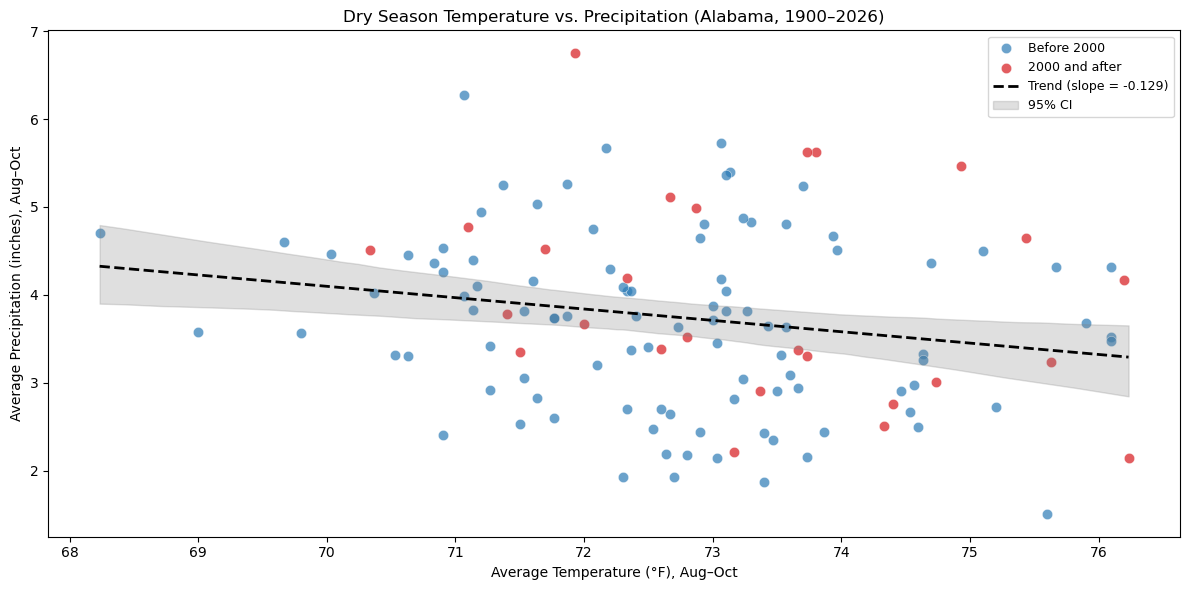

In [18]:
# Dry season scatter plot: temperature vs precipitation, pre/post 2000
# 125 years is too difficult to read on a scatter plot, so i decided to color code according to before or after year 2000
dry_merged['era'] = dry_merged['year'].apply(lambda y: 'Before 2000' if y < 2000 else '2000 and after')
dry_era_colors = {'Before 2000': '#2c7bb6', '2000 and after': '#d7191c'}

fig, ax = plt.subplots(figsize=(12, 6))
for era, color in dry_era_colors.items():
    mask = dry_merged['era'] == era
    ax.scatter(
        dry_merged.loc[mask, 'dry_temp_avg'],
        dry_merged.loc[mask, 'dry_season_avg'],
        color=color, label=era, alpha=0.7, s=55, edgecolors='white', linewidths=0.4
    )
x = dry_merged['dry_temp_avg'].values
y = dry_merged['dry_season_avg'].values
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 200)
y_line = m * x_line + b

#this is bootstrapping - finding middle 95% of 500 trend lines (shaded part on graph)
rng = np.random.default_rng(0)
boot_lines = []
for _ in range(500):
    idx = rng.integers(0, len(x), len(x))
    mb = np.polyfit(x[idx], y[idx], 1)
    boot_lines.append(mb[0] * x_line + mb[1])
boot_lines = np.array(boot_lines)
lower, upper = np.percentile(boot_lines, [2.5, 97.5], axis=0)

#now I am building the plot after defining my year and bootstrapping
ax.plot(x_line, y_line, color='black', linewidth=2, linestyle='--',
        label=f'Trend (slope = {m:.3f})')
ax.fill_between(x_line, lower, upper, color='gray', alpha=0.25, label='95% CI')

ax.set_title('Dry Season Temperature vs. Precipitation (Alabama, 1900–2026)')
ax.set_xlabel('Average Temperature (°F), Aug–Oct')
ax.set_ylabel('Average Precipitation (inches), Aug–Oct')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Observation: it seems that warmer dry seasons tend to bring less rainfall, with a slope of -0.129. The confidence band I generated from bootstrapping is relatively narrow. I decided to visualize the difference between after year 2000 and before 2000 in different colors because I was curious to see if precipitation events tend to be more exreme in recent years. There is an outlier at 72F with close to 7 inches. We also see red being more aggregated towards warmer temperatures, and near higher precipitation values, suggesting unusually wet dry seasons in recent years.

In [19]:
#Figure 3: Pearson correlation + rolling 20-year correlation (dry season) ─

r, p_value = stats.pearsonr(dry_merged['dry_temp_avg'], dry_merged['dry_season_avg'])

print(f"Pearson Correlation Coefficient (r): {r:.4f}")
print(f"P-value:                             {p_value:.4f}")
print()
if p_value < 0.05:
    print("Result: The correlation IS statistically significant (p < 0.05).")
else:
    print("Result: The correlation is NOT statistically significant (p >= 0.05).")

if abs(r) < 0.2:
    strength = "negligible"
elif abs(r) < 0.4:
    strength = "weak"
elif abs(r) < 0.6:
    strength = "moderate"
else:
    strength = "strong"

direction = "positive" if r > 0 else "negative"
print(f"Interpretation: {strength.capitalize()} {direction} correlation between dry season temperature and precipitation.")

Pearson Correlation Coefficient (r): -0.1975
P-value:                             0.0266

Result: The correlation IS statistically significant (p < 0.05).
Interpretation: Negligible negative correlation between dry season temperature and precipitation.


Observation: The pearson correlation retunrs a significant negative relationship between precipitation and temperature in Alabama during the dry season over 125 years. 

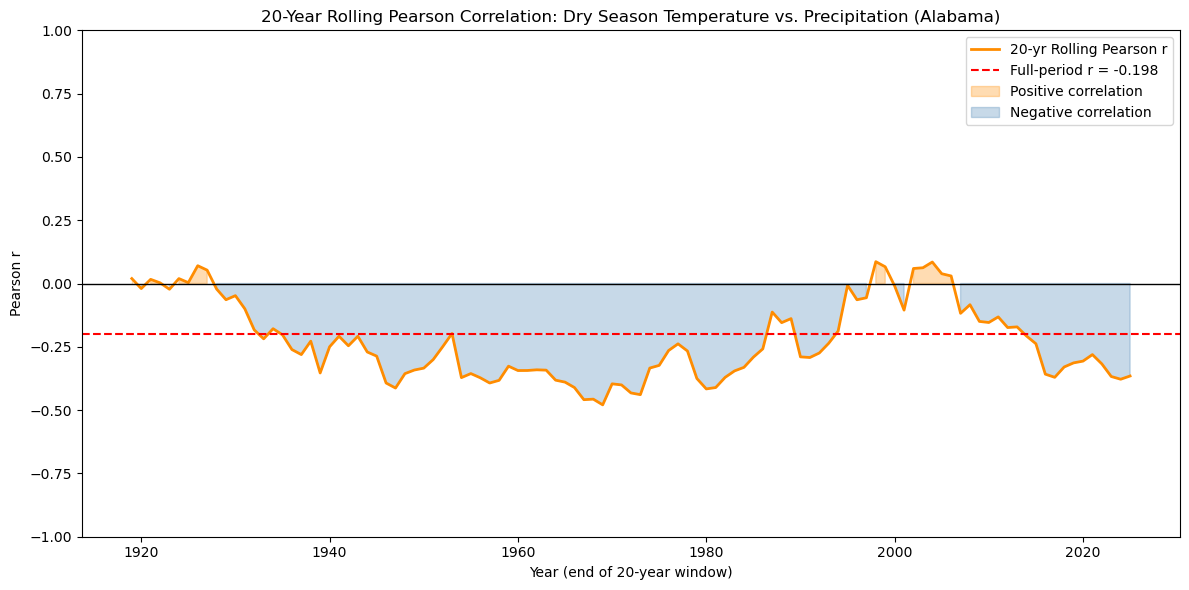

In [20]:
# Rolling 20-year correlation for dry season
window = 20
rolling_r = [
    stats.pearsonr(
        dry_merged['dry_temp_avg'].iloc[i:i+window].values,
        dry_merged['dry_season_avg'].iloc[i:i+window].values
    )[0]
    for i in range(len(dry_merged) - window + 1)
]
rolling_r = np.array(rolling_r)
rolling_years = dry_merged['year'].iloc[window - 1:].values

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(rolling_years, rolling_r, color='darkorange', linewidth=2, label='20-yr Rolling Pearson r')
ax.axhline(0, color='black', linewidth=1)
ax.axhline(r, color='red', linewidth=1.5, linestyle='--', label=f'Full-period r = {r:.3f}')
ax.fill_between(rolling_years, rolling_r, 0,
                where=(rolling_r >= 0), color='darkorange', alpha=0.3, label='Positive correlation')
ax.fill_between(rolling_years, rolling_r, 0,
                where=(rolling_r < 0), color='steelblue', alpha=0.3, label='Negative correlation')
ax.set_title('20-Year Rolling Pearson Correlation: Dry Season Temperature vs. Precipitation (Alabama)')
ax.set_xlabel('Year (end of 20-year window)')
ax.set_ylabel('Pearson r')
ax.set_ylim(-1, 1)
ax.legend()
plt.tight_layout()
plt.show()

To remember: a rolling Pearson correlation measures the linear relationship between the two time-series variables across a fixed-size window. It helps visualize how the strength and direction of a correlation (ranging from -1 to 1) fluctuate over time rather than remaining constant.

Observation: the overall relationship is negative (r=-0.198). Even if the effect is weak, this graph shows a negative relationship during the dry season between precipitation and temperatures. When noticing the negative relationship after 2010, it could emphasize that hot temperatures could lead to dry seasons in Alabama. According to the last graph, hotter years are dryier years, but that does not mean that Alabama should not expect flash floods and other brief stormy events. However, the previous upward trend showing an increase in precipitation in the dry season suggests that Alabama's dry season is more stronlgy influenced by year-to-year climate variability.  

### Conclusion

In conclusion, the results do not support our original hypothesis. Over 125 years of NOAA statewide data, our analysis found only partial support for dry get drier hypothesis. The wet season January-March showed no meaninful relationship between temperature and precipitation (pearson r = 0.057, slope=0.025), with the rolling correlation chat revealing unstable and inconsistent relationship that flipped sign multiple times across the century. This suggested that temperature alone does not drive wet season rainfall intensity. 
The dry season August- October showed consistently negative temperature-precipitation relationship (r=-0.198, slope=-0.129), suggesting warmer dry seasons tend to be drier ones. This partially supports dry gets drier hypothesis. 

Overall, Alabama's seasonsal rainfall patterns appear to be driven more by large scake climate variability than by simple average temperature trends. Future research would likley require analyzing extreme rainfall events and storms during the dry season, as we know that summer heat tends to bring stormy weather. 
